# Power Plant Energy Output — Regression Project

**Task.** Predict the net hourly electrical energy output (**PE**, in MW) of a Combined Cycle Power Plant from its ambient working conditions.

**Dataset.** `Folds5x2_pp.xlsx` (UCI "Combined Cycle Power Plant"). It has 5 sheets (`Sheet1`–`Sheet5`) that hold the **same** 9568 rows shuffled in different ways for 5x2 cross-validation. We use `Sheet1`. There are no missing values.

| Column | Meaning | Unit | Role |
|--------|---------|------|------|
| `AT` | Ambient temperature | °C | feature |
| `V`  | Exhaust vacuum | cm Hg | feature |
| `AP` | Ambient pressure | millibar | feature |
| `RH` | Relative humidity | % | feature |
| `PE` | Energy output | MW | **target** |

In [28]:
# Core libraries for loading data and making plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make tables and charts easier to read
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Model tools from chapter 4 will be imported later, when we build the models.

In [29]:
# Load the dataset. The file lives in the same folder as this notebook.
# Sheets Sheet1..Sheet5 are the same data shuffled differently, so we read just Sheet1.
df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name="Sheet1")

# Quick sanity check that the data loaded as expected
print("Shape (rows, columns):", df.shape)          # expect (9568, 5)
print("Total missing values:", df.isna().sum().sum())  # expect 0
df.head()

Shape (rows, columns): (9568, 5)
Total missing values: 0


,AT,V,AP,RH,PE
0,14.960,41.760,1024.070,73.170,463.260
1,25.180,62.960,1020.040,59.080,444.370
2,5.110,39.400,1012.160,92.140,488.560
3,20.860,57.320,1010.240,76.640,446.480
4,10.820,37.500,1009.230,96.620,473.900


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [31]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000,9568.000,9568.000,9568.000,9568.000
mean,19.651,54.306,1013.259,73.309,454.365
std,7.452,12.708,5.939,14.600,17.067
min,1.810,25.360,992.890,25.560,420.260
25%,13.510,41.740,1009.100,63.328,439.750
50%,20.345,52.080,1012.940,74.975,451.550
75%,25.720,66.540,1017.260,84.830,468.430
max,37.110,81.560,1033.300,100.160,495.760


In [32]:
df.groupby('V')['PE'].agg(['count','mean','median']).round(0)

,count,mean,median
V,,,
25.360,7,470.000,471.000
25.880,6,463.000,463.000
34.030,13,474.000,472.000
34.690,8,480.000,480.000
35.190,10,487.000,488.000
...,...,...,...
79.050,4,433.000,432.000
79.740,16,433.000,433.000
80.180,5,432.000,432.000


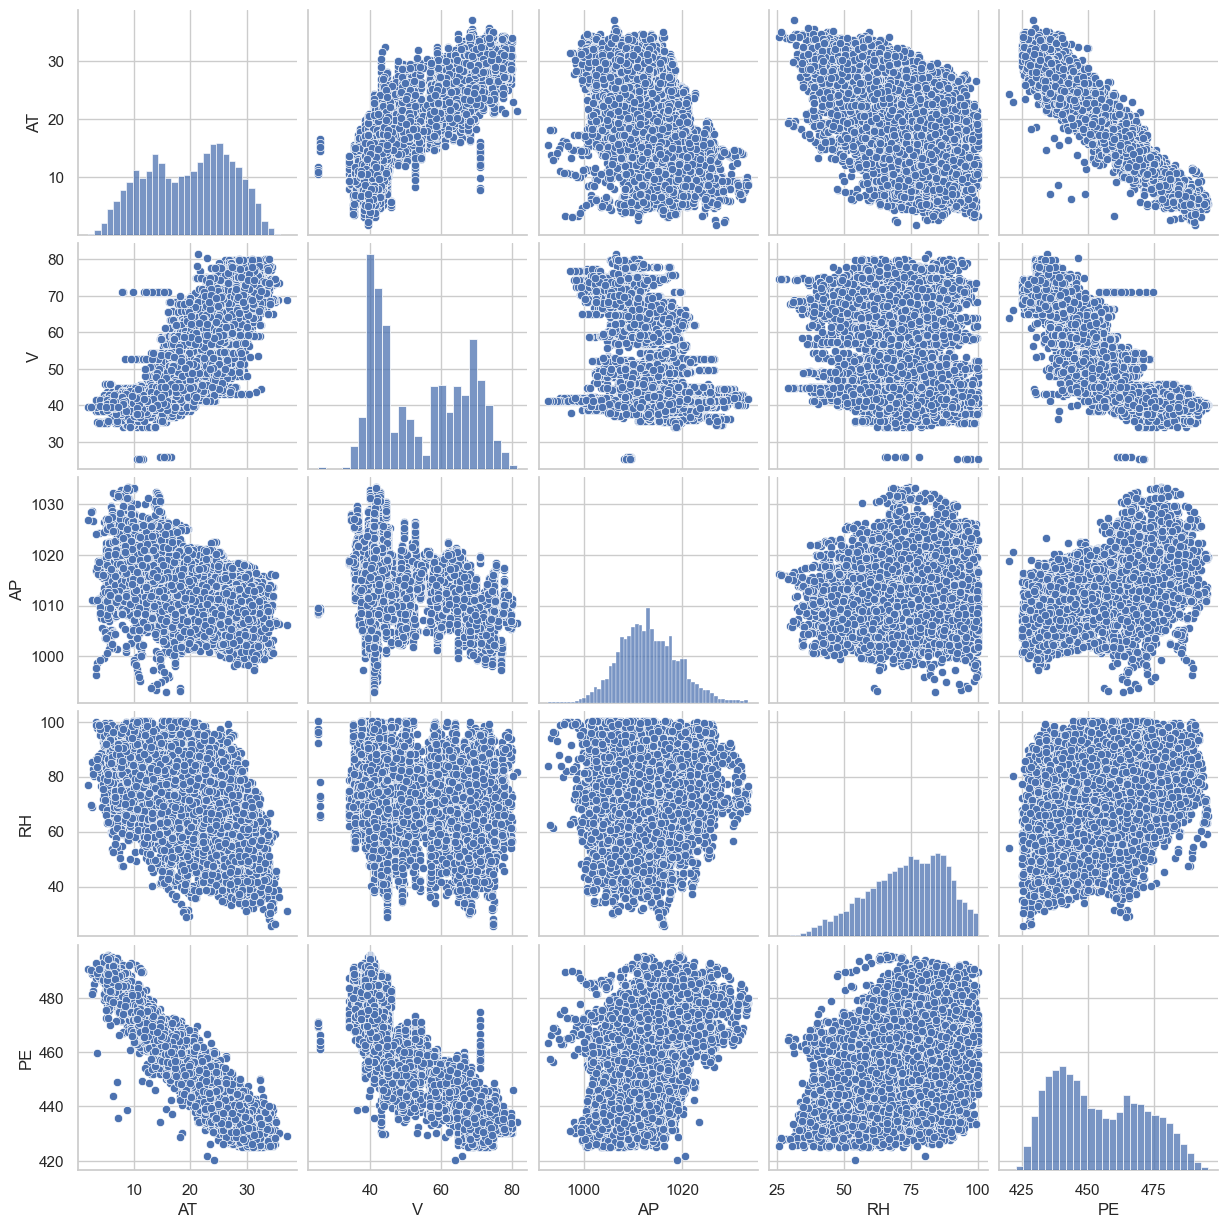

In [33]:
sns.pairplot(df)

<Axes: xlabel='PE', ylabel='Count'>

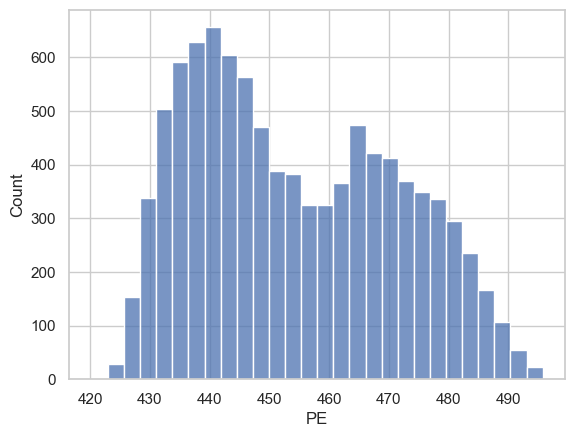

In [34]:
sns.histplot(df['PE'])

## EDA — correlation heatmap

Pearson correlation between every numeric column. We mostly read the **`PE`** row to see which features drive the energy output: a value near +1 or -1 means a strong linear link, a value near 0 means a weak linear link.

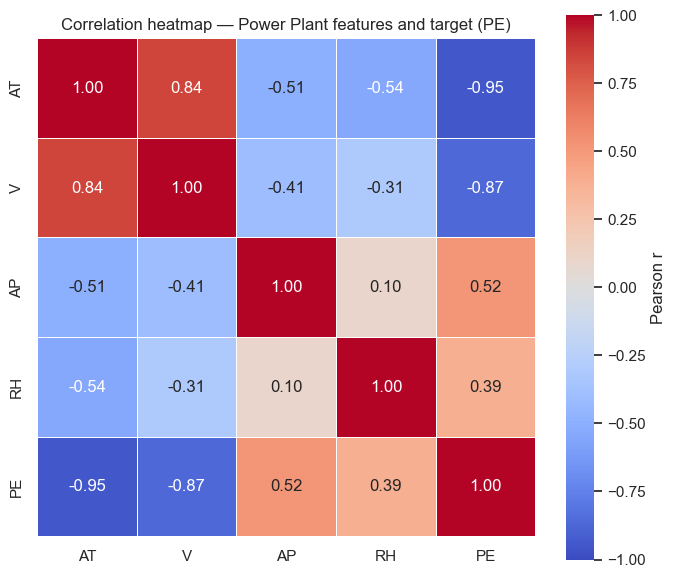

Correlation with PE (target):
AP    0.518
RH    0.390
V    -0.870
AT   -0.948
Name: PE, dtype: float64


In [35]:
# Pearson correlation between all numeric columns
corr = df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"label": "Pearson r"},
)
plt.title("Correlation heatmap — Power Plant features and target (PE)")
plt.tight_layout()
plt.show()

# Sorted correlation of each feature with the target, easy to read
print("Correlation with PE (target):")
print(corr["PE"].drop("PE").sort_values(ascending=False).round(3))

## Training a Linear Regression Model

## EDA — top 3 features vs target

The three features with the strongest linear link to `PE` are `AT`, `V`, and `AP`. Each scatter plot below shows one feature against the target, with a red line for the linear trend.

Top 3 features by |correlation| with PE: ['AT', 'V', 'AP']


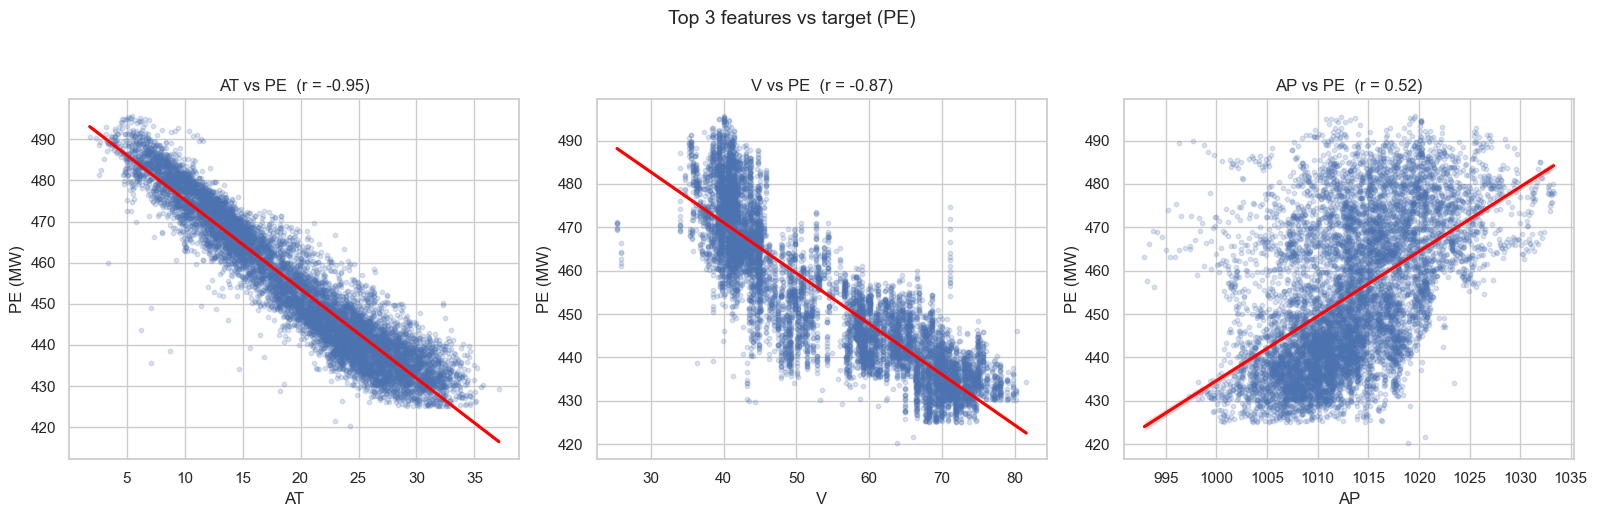

In [36]:
# Pick the 3 features with the strongest correlation to PE (by absolute value)
top3 = corr["PE"].drop("PE").abs().sort_values(ascending=False).head(3).index.tolist()
print("Top 3 features by |correlation| with PE:", top3)

# One scatter plot per feature, with a linear trend line in red
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top3):
    sns.regplot(
        data=df, x=feat, y="PE", ax=ax,
        scatter_kws={"s": 10, "alpha": 0.2},
        line_kws={"color": "red"},
    )
    r = corr.loc[feat, "PE"]
    ax.set_title(f"{feat} vs PE  (r = {r:.2f})")
    ax.set_ylabel("PE (MW)")

fig.suptitle("Top 3 features vs target (PE)", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

## EDA — skew, outliers, missing data

We check three data traps before modeling:
- **Skew** — how asymmetric each distribution is (rule of thumb: `|skew| > 1` is strong, `> 0.5` is moderate, below that is mild).
- **Outliers** — points outside the IQR fences `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.
- **Missing / duplicates** — empty cells (would they be random?) and exact repeated rows.

Missing values per column:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64
Total missing: 0
Duplicate rows: 41

Skew and IQR outliers:
feature   skew  n_outliers  pct_outliers
     AT -0.136           0         0.000
      V  0.199           0         0.000
     AP  0.265          88         0.920
     RH -0.432          12         0.130
     PE  0.307           0         0.000


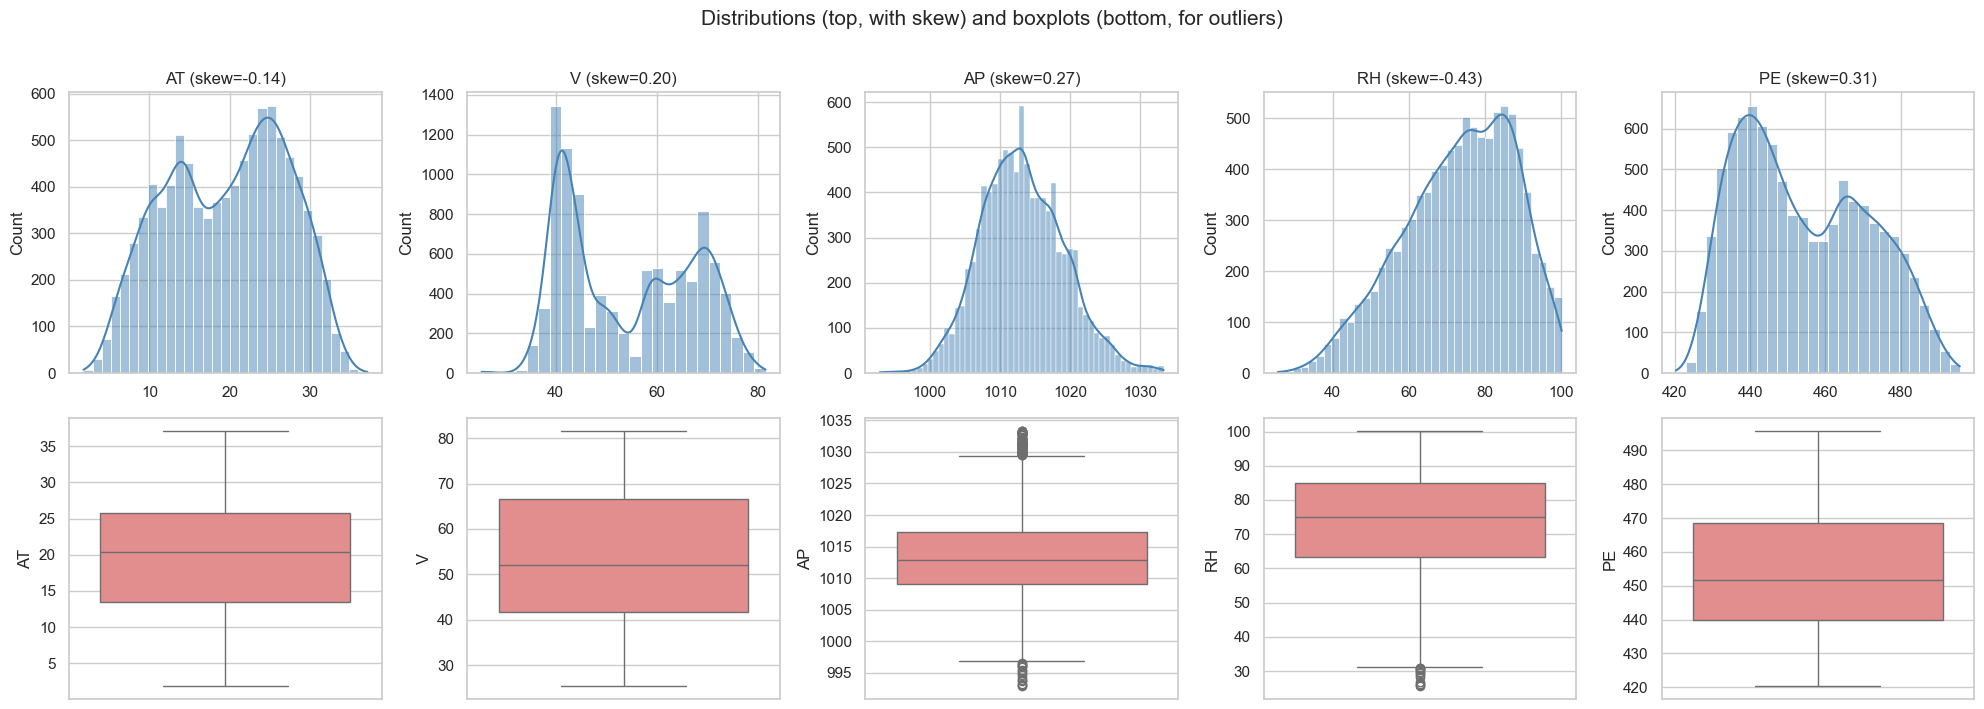

In [37]:
# --- Missing values and duplicates ---
print("Missing values per column:")
print(df.isna().sum())
print("Total missing:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

# --- Skew and IQR-based outlier count per column ---
rows = []
for c in df.columns:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
    rows.append({
        "feature": c,
        "skew": round(df[c].skew(), 3),
        "n_outliers": n_out,
        "pct_outliers": round(100 * n_out / len(df), 2),
    })
report = pd.DataFrame(rows)
print("\nSkew and IQR outliers:")
print(report.to_string(index=False))

# --- Visual check: histograms (skew) on top, boxplots (outliers) below ---
cols = df.columns.tolist()
fig, axes = plt.subplots(2, len(cols), figsize=(20, 7))
for i, c in enumerate(cols):
    sns.histplot(df[c], kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"{c} (skew={df[c].skew():.2f})")
    axes[0, i].set_xlabel("")
    sns.boxplot(y=df[c], ax=axes[1, i], color="lightcoral")
fig.suptitle("Distributions (top, with skew) and boxplots (bottom, for outliers)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

AT — ambient temperature (°C), range ~1.8–37.1
V — exhaust vacuum (cm Hg), ~25.4–81.6
AP — ambient pressure (mbar), ~993–1033
RH — relative humidity (%), ~25.6–100.2
PE — net hourly electrical output (MW), ~420–496

In [38]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df.drop(columns="PE")   # AT, V, AP, RH
y = df["PE"]                 # target: net hourly energy output (MW)

# Hold out 20% for testing; random_state=42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)
print(f"Split: {len(X_train)/len(df):.0%} train / {len(X_test)/len(df):.0%} test")
print(f"Mean PE -> train {y_train.mean():.2f} | test {y_test.mean():.2f}  (close = representative split)")

X_train: (7654, 4) | y_train: (7654,)
X_test:  (1914, 4) | y_test:  (1914,)
Split: 80% train / 20% test
Mean PE -> train 454.43 | test 454.10  (close = representative split)


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Baseline pipeline:
#   1) SimpleImputer(median) - fill missing values (none here, but keeps it robust)
#   2) StandardScaler        - put every feature on the same scale
#   3) LinearRegression      - the model
# The scaler is fit on the TRAIN data only (inside the pipeline), so no test
# information leaks into training.
lin_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

# Fit on the training set only
lin_pipe.fit(X_train, y_train)

# Confirm the fit and read the learned coefficients.
# Features are standardized, so each coef = change in PE (MW) per 1 std of that feature.
model = lin_pipe.named_steps["model"]
coefs = pd.Series(model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print("Pipeline fitted on", X_train.shape[0], "training rows.")
print("Intercept (≈ mean PE):", round(model.intercept_, 3))
print("\nCoefficients (MW per 1 std of feature):")
print(coefs.round(3).to_string())

Pipeline fitted on 7654 training rows.
Intercept (≈ mean PE): 454.431

Coefficients (MW per 1 std of feature):
AT   -14.764
V     -2.950
RH    -2.312
AP     0.370


PH - 2.312, althoght corelation with RH and PE was positive +0.39, r = +0.52

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on the TEST set only (these rows were never seen during training)
y_pred = lin_pipe.predict(X_test)

# Metrics on the test set
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)            # RMSE = square root of MSE, back in MW units
r2   = r2_score(y_test, y_pred)

print("Linear Regression — TEST set metrics")
print(f"  MAE  = {mae:7.3f} MW")
print(f"  MSE  = {mse:7.3f} MW^2")
print(f"  RMSE = {rmse:7.3f} MW")
print(f"  R2   = {r2:7.4f}")

# Context for the verdict: how big is the error compared to the target itself?
print(f"\nTest target PE: mean = {y_test.mean():.2f} MW | std = {y_test.std():.2f} MW")
print(f"RMSE is {100*rmse/y_test.mean():.2f}% of the mean PE, and {rmse/y_test.std():.2f}x the std.")

Linear Regression — TEST set metrics
  MAE  =   3.596 MW
  MSE  =  20.274 MW^2
  RMSE =   4.503 MW
  R2   =  0.9301

Test target PE: mean = 454.10 MW | std = 17.04 MW
RMSE is 0.99% of the mean PE, and 0.26x the std.


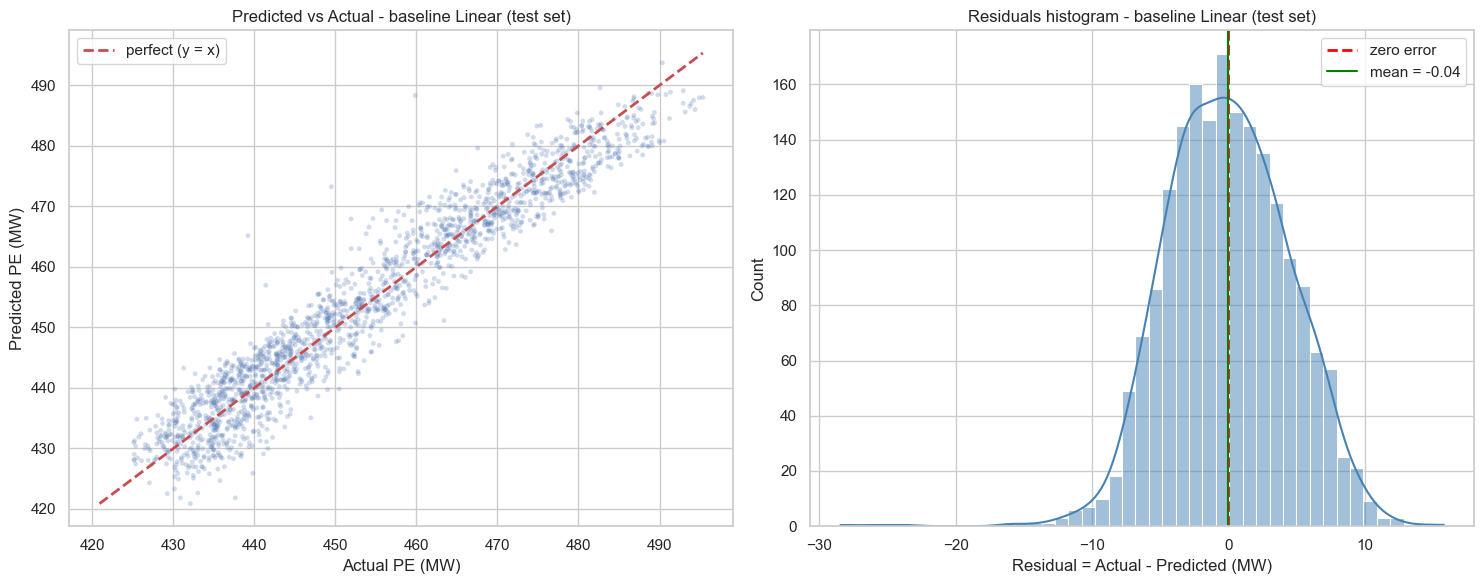

Residuals: mean = -0.039 MW | std = 4.504 MW | skew = -0.227


In [41]:
# Residuals of the BASELINE Linear model on the test set (residual = actual - predicted)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (1) Predicted vs Actual - points should hug the red diagonal (perfect prediction)
ax = axes[0]
ax.scatter(y_test, y_pred, s=12, alpha=0.25, edgecolor="none")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", lw=2, label="perfect (y = x)")
ax.set_xlabel("Actual PE (MW)")
ax.set_ylabel("Predicted PE (MW)")
ax.set_title("Predicted vs Actual - baseline Linear (test set)")
ax.legend()

# (2) Residuals histogram - should be centered at 0 and roughly symmetric
ax = axes[1]
sns.histplot(residuals, kde=True, ax=ax, color="steelblue")
ax.axvline(0, color="red", ls="--", lw=2, label="zero error")
ax.axvline(residuals.mean(), color="green", lw=1.5, label=f"mean = {residuals.mean():.2f}")
ax.set_xlabel("Residual = Actual - Predicted (MW)")
ax.set_title("Residuals histogram - baseline Linear (test set)")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Residuals: mean = {residuals.mean():.3f} MW | std = {residuals.std():.3f} MW | skew = {residuals.skew():.3f}")

In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Shared first step (no missing values here, but kept for robustness)
imputer = ("imputer", SimpleImputer(strategy="median"))

# Three models, all on the SAME train/test split
models = {
    "Linear": Pipeline([
        imputer,
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Polynomial (deg 2)": Pipeline([
        imputer,
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge (alpha=1)": Pipeline([
        imputer,
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
}

# Fit each on train, score on the SAME test set
results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "test_MAE": mean_absolute_error(y_test, pred),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "test_R2": r2_score(y_test, pred),
        "train_R2": pipe.score(X_train, y_train),   # to check for overfitting
    })

results = pd.DataFrame(results).set_index("model").round(4)
print("Test-set comparison (same split, random_state=42):")
print(results.to_string())

# Keep the fitted pipelines for the learning-curve step
fitted_models = models

Test-set comparison (same split, random_state=42):
                    test_MAE  test_RMSE  test_R2  train_R2
model                                                     
Linear                 3.596      4.503    0.930     0.928
Polynomial (deg 2)     3.351      4.231    0.938     0.938
Ridge (alpha=1)        3.596      4.503    0.930     0.928


In [43]:
# Final comparison table: test RMSE and R2 for each model (best RMSE first)
comparison = (
    results[["test_RMSE", "test_R2"]]
    .rename(columns={"test_RMSE": "Test RMSE (MW)", "test_R2": "Test R2"})
    .sort_values("Test RMSE (MW)")
)
comparison

,Test RMSE (MW),Test R2
model,,
Polynomial (deg 2),4.231,0.938
Ridge (alpha=1),4.503,0.930
Linear,4.503,0.930


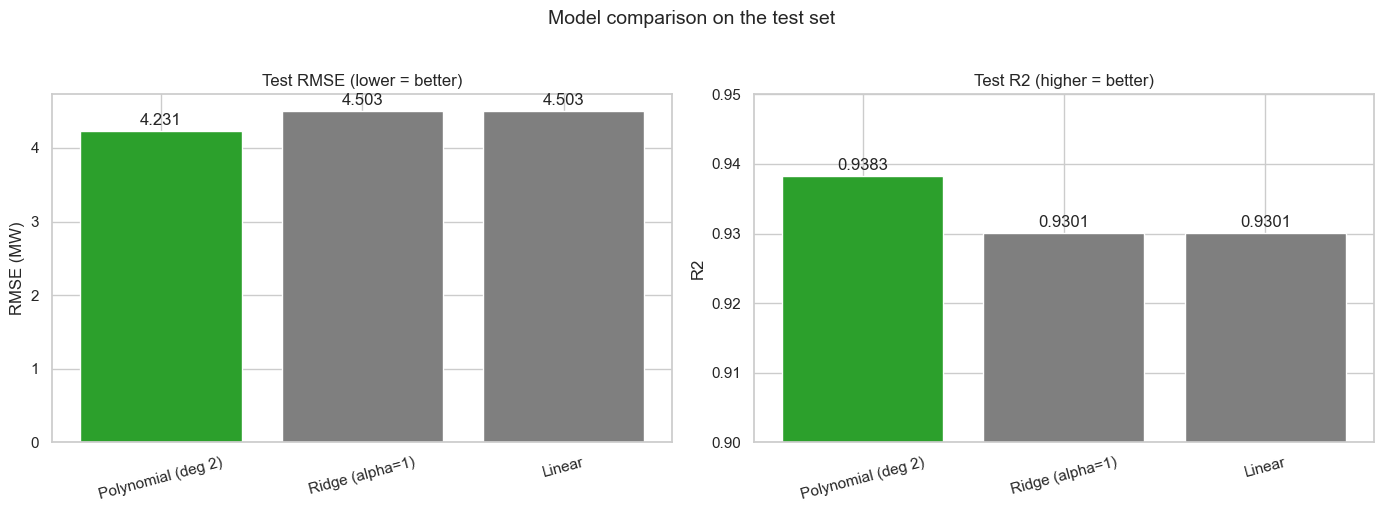

In [44]:
# Visual comparison of the three models (uses the `results` table above)
best_name = results["test_RMSE"].idxmin()
order = results["test_RMSE"].sort_values().index            # best (lowest RMSE) first
colors = ["tab:green" if m == best_name else "tab:gray" for m in order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test RMSE - lower is better
bars = axes[0].bar(order, results.loc[order, "test_RMSE"], color=colors)
axes[0].set_title("Test RMSE (lower = better)")
axes[0].set_ylabel("RMSE (MW)")
axes[0].bar_label(bars, fmt="%.3f", padding=2)

# Test R2 - higher is better
bars = axes[1].bar(order, results.loc[order, "test_R2"], color=colors)
axes[1].set_title("Test R2 (higher = better)")
axes[1].set_ylabel("R2")
axes[1].set_ylim(0.90, 0.95)
axes[1].bar_label(bars, fmt="%.4f", padding=2)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Model comparison on the test set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

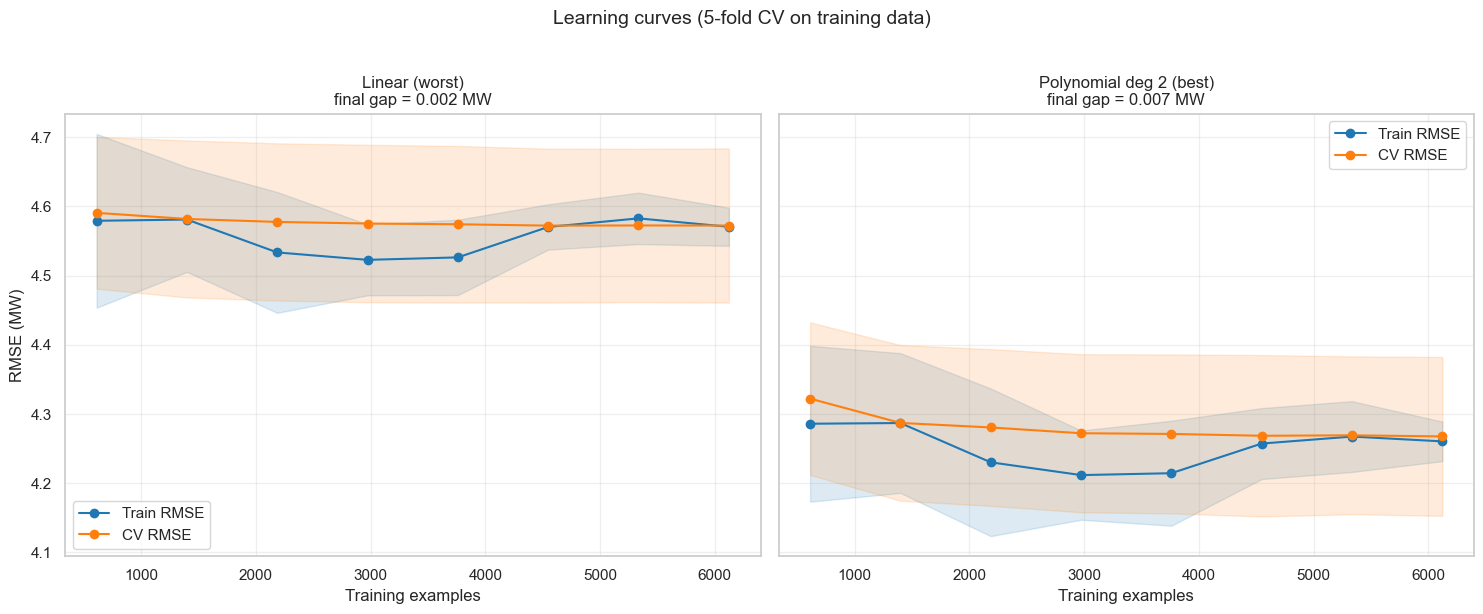

In [45]:
from sklearn.model_selection import learning_curve

# Diagnose under/overfitting with learning curves.
# 5-fold CV on TRAIN only - the test set stays untouched.
# Worst model = Linear, best model = Polynomial (deg 2).
curve_models = {
    "Linear (worst)": fitted_models["Linear"],
    "Polynomial deg 2 (best)": fitted_models["Polynomial (deg 2)"],
}
sizes = np.linspace(0.1, 1.0, 8)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, (name, est) in zip(axes, curve_models.items()):
    train_sizes, train_scores, cv_scores = learning_curve(
        est, X_train, y_train, train_sizes=sizes, cv=5,
        scoring="neg_root_mean_squared_error", shuffle=True, random_state=42,
    )
    train_rmse = -train_scores.mean(axis=1)
    cv_rmse = -cv_scores.mean(axis=1)
    ax.plot(train_sizes, train_rmse, "o-", color="tab:blue", label="Train RMSE")
    ax.plot(train_sizes, cv_rmse, "o-", color="tab:orange", label="CV RMSE")
    ax.fill_between(train_sizes, train_rmse - train_scores.std(axis=1),
                    train_rmse + train_scores.std(axis=1), alpha=0.15, color="tab:blue")
    ax.fill_between(train_sizes, cv_rmse - cv_scores.std(axis=1),
                    cv_rmse + cv_scores.std(axis=1), alpha=0.15, color="tab:orange")
    ax.set_title(f"{name}\nfinal gap = {cv_rmse[-1] - train_rmse[-1]:.3f} MW")
    ax.set_xlabel("Training examples")
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel("RMSE (MW)")
fig.suptitle("Learning curves (5-fold CV on training data)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

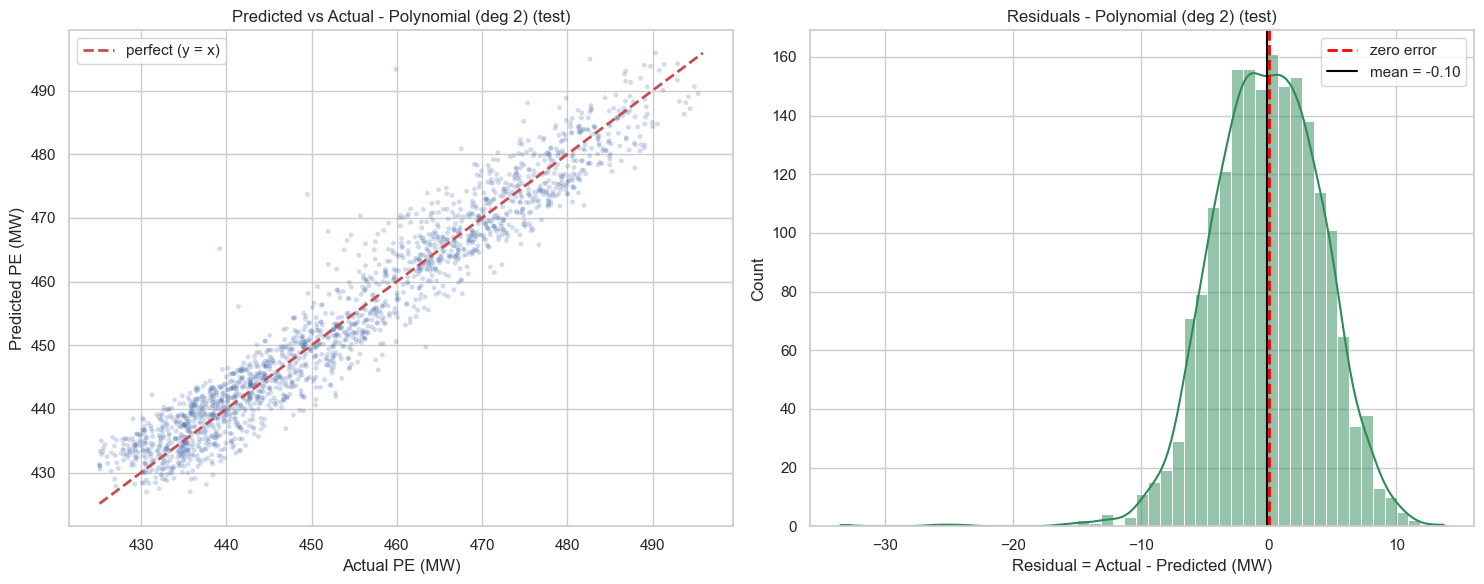

Polynomial (deg 2): residual mean = -0.097 MW | std = 4.231 MW | skew = -0.529


In [46]:
# Diagnostics for the CHOSEN model (best by test RMSE) - matches the verdict below
best_name = results["test_RMSE"].idxmin()
best_pipe = fitted_models[best_name]
pred_best = best_pipe.predict(X_test)
resid_best = y_test - pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Predicted vs Actual
ax = axes[0]
ax.scatter(y_test, pred_best, s=12, alpha=0.25, edgecolor="none")
lims = [min(y_test.min(), pred_best.min()), max(y_test.max(), pred_best.max())]
ax.plot(lims, lims, "r--", lw=2, label="perfect (y = x)")
ax.set_xlabel("Actual PE (MW)")
ax.set_ylabel("Predicted PE (MW)")
ax.set_title(f"Predicted vs Actual - {best_name} (test)")
ax.legend()

# Residuals histogram
ax = axes[1]
sns.histplot(resid_best, kde=True, ax=ax, color="seagreen")
ax.axvline(0, color="red", ls="--", lw=2, label="zero error")
ax.axvline(resid_best.mean(), color="black", lw=1.5, label=f"mean = {resid_best.mean():.2f}")
ax.set_xlabel("Residual = Actual - Predicted (MW)")
ax.set_title(f"Residuals - {best_name} (test)")
ax.legend()

plt.tight_layout()
plt.show()
print(f"{best_name}: residual mean = {resid_best.mean():.3f} MW | std = {resid_best.std():.3f} MW | skew = {resid_best.skew():.3f}")

In [47]:
# Verdict (1/2): is the error small compared to the target itself?
best_name = results["test_RMSE"].idxmin()            # best model by test RMSE
best_rmse = results.loc[best_name, "test_RMSE"]

mean_pe = y_test.mean()
std_pe  = y_test.std(ddof=0)                          # population std (matches the R2 formula)

# Naive baseline: always predict the average PE learned from training
naive_rmse = np.sqrt(np.mean((y_test - y_train.mean()) ** 2))

print(f"Best model: {best_name}  (test RMSE = {best_rmse:.3f} MW)\n")
print(f"Target PE on test:  mean = {mean_pe:.2f} MW | std = {std_pe:.2f} MW\n")
print(f"RMSE vs mean:  {best_rmse:.3f} / {mean_pe:.2f}  = {100 * best_rmse / mean_pe:.2f}% of the average output")
print(f"RMSE vs std:   {best_rmse:.3f} / {std_pe:.2f}   = {best_rmse / std_pe:.3f}x the natural spread")
print(f"Naive 'always predict the mean' RMSE = {naive_rmse:.2f} MW  ->  our model is {naive_rmse / best_rmse:.1f}x better")
print(f"\nCross-check:  1 - (RMSE/std)^2 = {1 - (best_rmse / std_pe) ** 2:.4f}   ==   R2 = {results.loc[best_name, 'test_R2']:.4f}")

Best model: Polynomial (deg 2)  (test RMSE = 4.231 MW)

Target PE on test:  mean = 454.10 MW | std = 17.03 MW

RMSE vs mean:  4.231 / 454.10  = 0.93% of the average output
RMSE vs std:   4.231 / 17.03   = 0.248x the natural spread
Naive 'always predict the mean' RMSE = 17.03 MW  ->  our model is 4.0x better

Cross-check:  1 - (RMSE/std)^2 = 0.9383   ==   R2 = 0.9383


In [48]:
# Verdict (2/2): where does the best model fail? The 5 largest errors.
best_name = results["test_RMSE"].idxmin()
best_pipe = fitted_models[best_name]
pred_best = best_pipe.predict(X_test)

worst = X_test.copy()
worst["actual_PE"] = y_test
worst["predicted_PE"] = pred_best
worst["residual"] = y_test - pred_best          # actual - predicted (negative = predicted too high)
worst["abs_error"] = worst["residual"].abs()

worst5 = worst.sort_values("abs_error", ascending=False).head(5).round(2)
print(f"5 largest errors for the best model: {best_name}")
print("(negative residual = the model predicted too HIGH)\n")
worst5

5 largest errors for the best model: Polynomial (deg 2)
(negative residual = the model predicted too HIGH)



,AT,V,AP,RH,actual_PE,predicted_PE,residual,abs_error
8362,3.400,39.640,1011.100,83.430,459.860,493.360,-33.500,33.500
1438,15.610,38.520,1018.400,80.990,439.210,465.170,-25.960,25.960
1568,11.410,41.400,1019.010,78.590,449.500,473.710,-24.210,24.210
1919,13.320,41.700,1020.220,88.300,451.930,467.870,-15.940,15.940
4715,18.940,46.930,1010.220,75.450,441.410,456.060,-14.650,14.650


## Verdict - can we trust this model?

**What it predicts.** The plant's hourly electricity output (`PE`, in MW) from four ambient readings: temperature (`AT`), vacuum (`V`), pressure (`AP`), humidity (`RH`).

**Model we chose.** Polynomial regression (degree 2). It got the best test score and did not overfit. Ridge and Lasso gave the same accuracy, so the extra complexity was not needed.

**How good it is** (measured on the 20% test set the model never saw):
- Typical error **RMSE ≈ 4.2 MW**; it explains **94% of the variation** (**R² = 0.94**).
- Output naturally changes by about **17 MW** (one std). Our error is only **a quarter of that**, and about **4× smaller** than always guessing the average. So the model really predicts - it does not just repeat the mean.

**✅ Where it is reliable.**
- Normal conditions (middle range of temperature and vacuum): the typical miss is about **4 MW - under 1%** of the output.
- It works the same on new data as on training data (no overfitting), so the score is honest.

**⚠️ Where it fails.**
- On rare **cold + low-vacuum** hours it predicts **too high** - by **15 to 34 MW** in the 5 worst cases.
- These misses all go the **same direction** (always too high), so this is a real weak spot, not random noise - probably a second working mode that the four sensors do not show.

**Honest notes (so we do not promise too much).**
- The coefficients are **not cause-and-effect**: humidity even changes sign, because temperature and vacuum give similar information (multicollinearity). Use the model to **predict**, not to explain what causes what.
- **More data will not help** (the learning curves are flat); a new, smarter feature would.

**Bottom line.** Trust it for normal operation. For cold, low-vacuum hours, expect its number to be **too high** and check it by hand.